<a href="https://colab.research.google.com/github/machancejoy-max/colab-git-demo-JOY/blob/main/Final_Project_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
# Import required Python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Download the Medical Cost dataset directly
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"

df = pd.read_csv(url)
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [32]:
# Explore dataset structure and summary statistics

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [33]:
print(df.describe)

<bound method NDFrame.describe of       age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]>


In [34]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


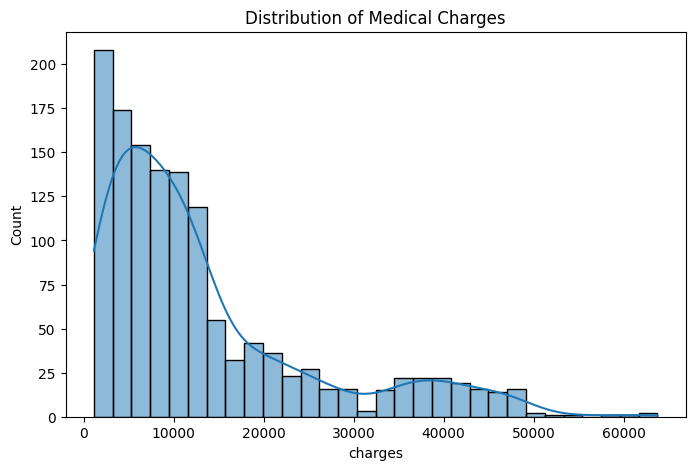

In [35]:
# Visualize distribution of medical charges

plt.figure(figsize=(8,5))
sns.histplot(df['charges'], kde=True)
plt.title("Distribution of Medical Charges")
plt.show()

In [36]:
#Encode categorical variables (sex, smoker, region)
df_encoded = df.copy()

label_cols = ['sex', 'smoker', 'region']
encoder = LabelEncoder()

for col in label_cols:
    df_encoded[col] = encoder.fit_transform(df_encoded[col])



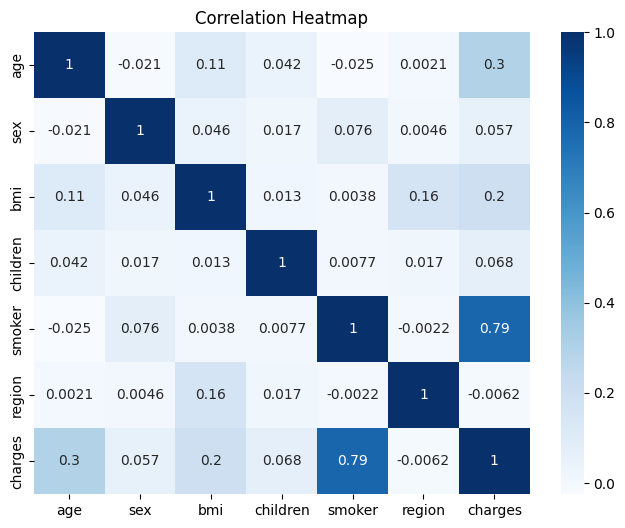

In [37]:
#Correlation heatmap for numeric features
plt.figure(figsize=(8,6))
sns.heatmap(df_encoded.corr(), annot=True, cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()

In [38]:
#Split features (X) and target (y)
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

In [39]:
#Normalize features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [40]:
#Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split( X_scaled, y, test_size=0.2, random_state=42)

In [41]:
#Train a Random Forest Regressor
model = RandomForestRegressor( n_estimators=200, max_depth=15, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, n_estimators=200, random_state=42)

In [42]:
#Evaluate model performance
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R² Score:", r2)

RMSE: 4531.587586395404
MAE: 2473.680735207898
R² Score: 0.8677265452937948


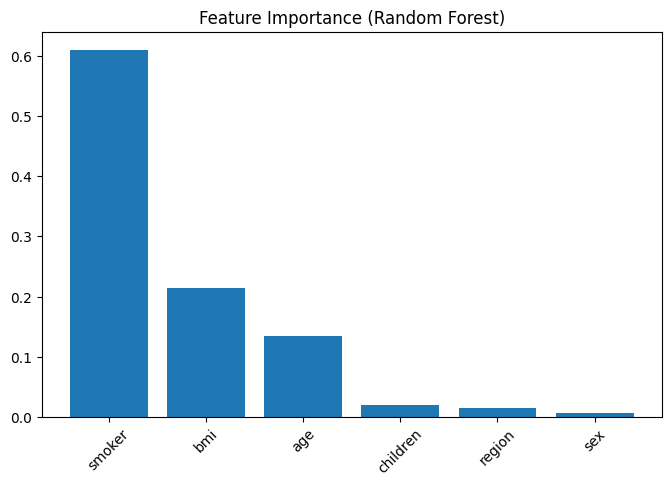

In [43]:
# Plot feature importance
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = X.columns

plt.figure(figsize=(8,5))
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), feature_names[indices], rotation=45)
plt.title("Feature Importance (Random Forest)")
plt.show()

In [44]:
#Simple function to predict medical cost
def predict_cost(age, sex, bmi, children, smoker, region):
    # Encode categorical inputs
    sex = encoder.fit(df['sex']).transform([sex])[0]
    smoker = encoder.fit(df['smoker']).transform([smoker])[0]
    region = encoder.fit(df['region']).transform([region])[0]

    # Create input array
    input_data = np.array([[age, sex, bmi, children, smoker, region]])

    # Scale input
    input_scaled = scaler.transform(input_data)

    # Predict
    prediction = model.predict(input_scaled)
    return prediction[0]

# Example prediction
predict_cost(30, "male", 28.5, 2, "no", "southeast")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


np.float64(6530.995889854226)